wrote /home/fenghuang/workspace/rope-first-principle/assets/score_matrix_animation.gif


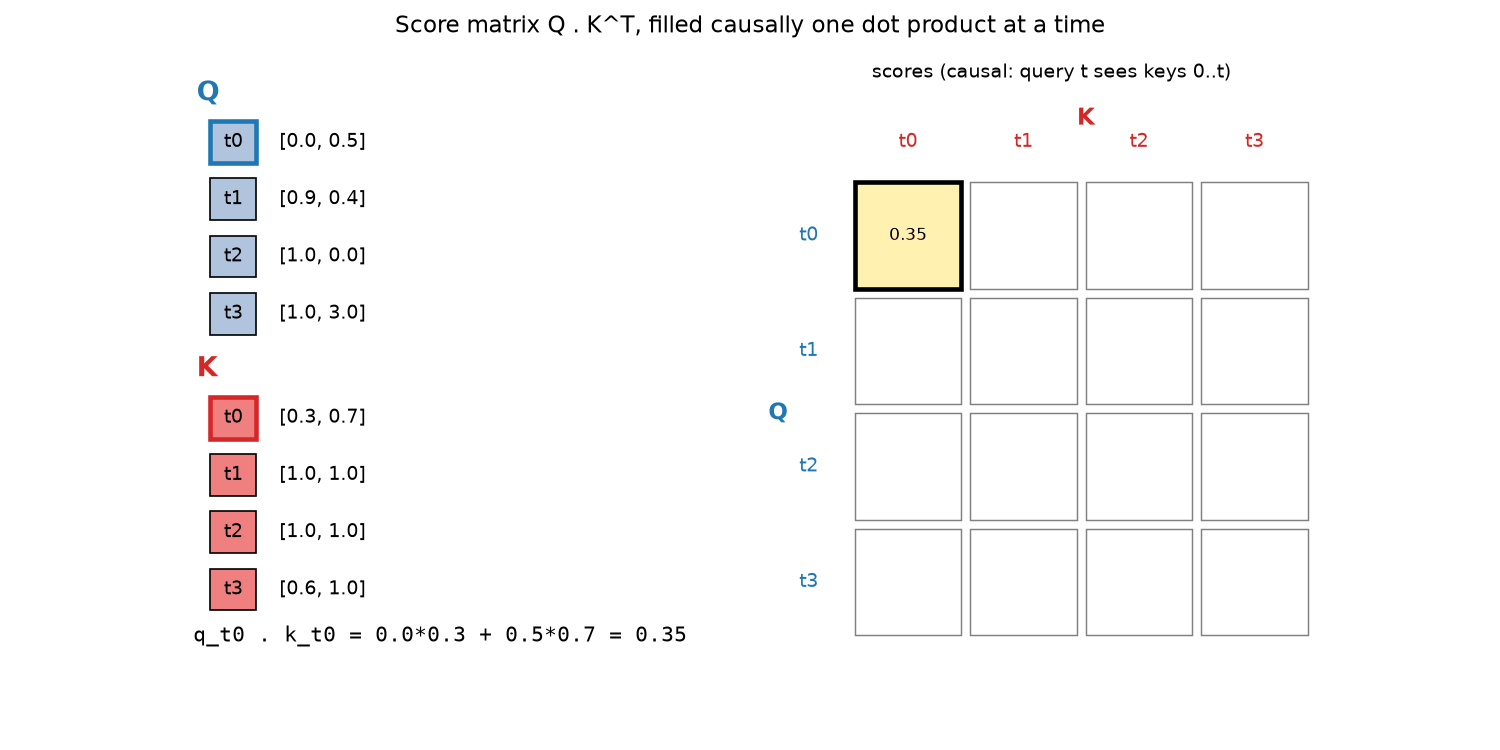

In [6]:
"""Animated Q.K score matrix, filled causally one cell per frame.

Layout follows the common attention-explainer diagram: the Q and K
vector lists on the left, the score grid on the right. Each frame
highlights one (query, key) pair, computes their dot product for real,
and fills the corresponding cell with its value and a color mapped to
its magnitude. Cells fill in causal order: query t only attends to keys
0..t, so the grid fills as a lower triangle.

Vectors here are small 2D examples so every dot product is checkable by
hand from the numbers shown on the left.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as score_matrix_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Rectangle

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "score_matrix_animation.gif")


def build_animation(
    tokens: list[str] = None,
    q_vectors: np.ndarray = None,
    k_vectors: np.ndarray = None,
    output_path: str = OUTPUT_PATH,
) -> None:
    if tokens is None:
        tokens = ["t0", "t1", "t2", "t3"]
    if q_vectors is None:
        q_vectors = np.array([[0.0, 0.5],
                              [0.9, 0.4],
                              [1.0, 0.0],
                              [1.0, 3.0]])
    if k_vectors is None:
        k_vectors = np.array([[0.3, 0.7],
                              [1.0, 1.0],
                              [1.0, 1.0],
                              [0.6, 1.0]])

    n = len(tokens)
    scores = q_vectors @ k_vectors.T  # full matrix; only causal cells shown

    # Causal fill order: (0,0), (1,0), (1,1), (2,0), ...
    fill_order = [(t, j) for t in range(n) for j in range(t + 1)]

    causal_vals = [scores[t, j] for t, j in fill_order]
    vmin, vmax = min(causal_vals), max(causal_vals)
    cmap = plt.cm.YlOrBr

    def score_color(val: float):
        span = vmax - vmin if vmax > vmin else 1.0
        return cmap(0.15 + 0.7 * (val - vmin) / span)

    fig, (ax_vec, ax_grid) = plt.subplots(
        1, 2, figsize=(10, 5), dpi=150,
        gridspec_kw={"width_ratios": [1, 1.3]},
    )
    fig.suptitle("Score matrix Q . K^T, filled causally one dot product at a time",
                 fontsize=11)

    # ---- Left panel: Q and K vector lists ----
    ax_vec.set_xlim(0, 10)
    ax_vec.set_ylim(0, 10)
    ax_vec.axis("off")

    q_label_boxes, k_label_boxes = [], []
    row_height = 1.1
    q_top = 9.8
    k_gap = 0.8  # jarak antara blok Q dan blok K

    # k_top = posisi label "K" besar, tepat di atas kotak K pertama.
    q_last_box_bottom = (q_top - 0.8 - (n - 1) * row_height) - 0.4
    k_top = q_last_box_bottom - k_gap

    for i in range(n):
        y_q = q_top - 0.8 - i * row_height
        box = Rectangle((0.5, y_q - 0.4), 1.0, 0.8,
                        facecolor="lightsteelblue", edgecolor="black", linewidth=0.8)
        ax_vec.add_patch(box)
        q_label_boxes.append(box)
        ax_vec.text(1.0, y_q, tokens[i], ha="center", va="center", fontsize=9)
        ax_vec.text(2.0, y_q, f"[{q_vectors[i, 0]:.1f}, {q_vectors[i, 1]:.1f}]",
                    ha="left", va="center", fontsize=9)

        y_k = k_top - 0.8 - i * row_height
        box = Rectangle((0.5, y_k - 0.4), 1.0, 0.8,
                        facecolor="lightcoral", edgecolor="black", linewidth=0.8)
        ax_vec.add_patch(box)
        k_label_boxes.append(box)
        ax_vec.text(1.0, y_k, tokens[i], ha="center", va="center", fontsize=9)
        ax_vec.text(2.0, y_k, f"[{k_vectors[i, 0]:.1f}, {k_vectors[i, 1]:.1f}]",
                    ha="left", va="center", fontsize=9)

    k_last_box_bottom = (k_top - 0.8 - (n - 1) * row_height) - 0.4
    calc_y = k_last_box_bottom - 0.6

    ax_vec.text(0.2, q_top, "Q", fontsize=13, color="tab:blue", fontweight="bold")
    ax_vec.text(0.2, k_top, "K", fontsize=13, color="tab:red", fontweight="bold")
    calc_text = ax_vec.text(5.5, calc_y, "", fontsize=10, ha="center",
                            family="monospace")
    ax_vec.set_ylim(min(0, calc_y - 0.5), 10)

    # ---- Right panel: score grid ----
    ax_grid.set_xlim(-0.8, n + 0.2)
    ax_grid.set_ylim(-0.8, n + 0.2)
    ax_grid.invert_yaxis()
    ax_grid.set_aspect("equal")
    ax_grid.axis("off")
    ax_grid.set_title("scores (causal: query t sees keys 0..t)", fontsize=9)

    cell_patches = {}
    cell_texts = {}
    for t in range(n):
        for j in range(n):
            rect = Rectangle((j, t), 0.92, 0.92,
                             facecolor="white", edgecolor="gray", linewidth=0.7)
            ax_grid.add_patch(rect)
            cell_patches[(t, j)] = rect
            txt = ax_grid.text(j + 0.46, t + 0.46, "", ha="center", va="center",
                               fontsize=8)
            cell_texts[(t, j)] = txt

    for i in range(n):
        ax_grid.text(i + 0.46, -0.35, tokens[i], ha="center", va="center",
                     fontsize=9, color="tab:red")
        ax_grid.text(-0.4, i + 0.46, tokens[i], ha="center", va="center",
                     fontsize=9, color="tab:blue")
    ax_grid.text(n / 2, -0.50, "K", ha="center", fontsize=11,
                 color="tab:red", fontweight="bold")
    ax_grid.text(-0.75, n / 2, "Q", va="center", fontsize=11,
                 color="tab:blue", fontweight="bold")

    def update(frame_idx: int):
        t, j = fill_order[frame_idx]

        # Reset all fills up to this frame, then re-apply.
        for (tt, jj), rect in cell_patches.items():
            k = fill_order.index((tt, jj)) if (tt, jj) in fill_order else None
            if k is not None and k <= frame_idx:
                rect.set_facecolor(score_color(scores[tt, jj]))
                cell_texts[(tt, jj)].set_text(f"{scores[tt, jj]:.2f}")
            else:
                rect.set_facecolor("white")
                cell_texts[(tt, jj)].set_text("")
            rect.set_edgecolor("gray")
            rect.set_linewidth(0.7)

        # Highlight the current cell and the vectors that produced it.
        cell_patches[(t, j)].set_edgecolor("black")
        cell_patches[(t, j)].set_linewidth(2.2)

        for i, box in enumerate(q_label_boxes):
            box.set_linewidth(2.2 if i == t else 0.8)
            box.set_edgecolor("tab:blue" if i == t else "black")
        for i, box in enumerate(k_label_boxes):
            box.set_linewidth(2.2 if i == j else 0.8)
            box.set_edgecolor("tab:red" if i == j else "black")

        qv, kv = q_vectors[t], k_vectors[j]
        calc_text.set_text(
            f"q_{tokens[t]} . k_{tokens[j]} = "
            f"{qv[0]:.1f}*{kv[0]:.1f} + {qv[1]:.1f}*{kv[1]:.1f} "
            f"= {scores[t, j]:.2f}"
        )
        return []

    anim = FuncAnimation(fig, update, frames=len(fill_order),
                         interval=900, blit=False, repeat=True)
    writer = PillowWriter(fps=1.1)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

wrote /home/fenghuang/workspace/rope-first-principle/../assets/equal_distance_animation.gif


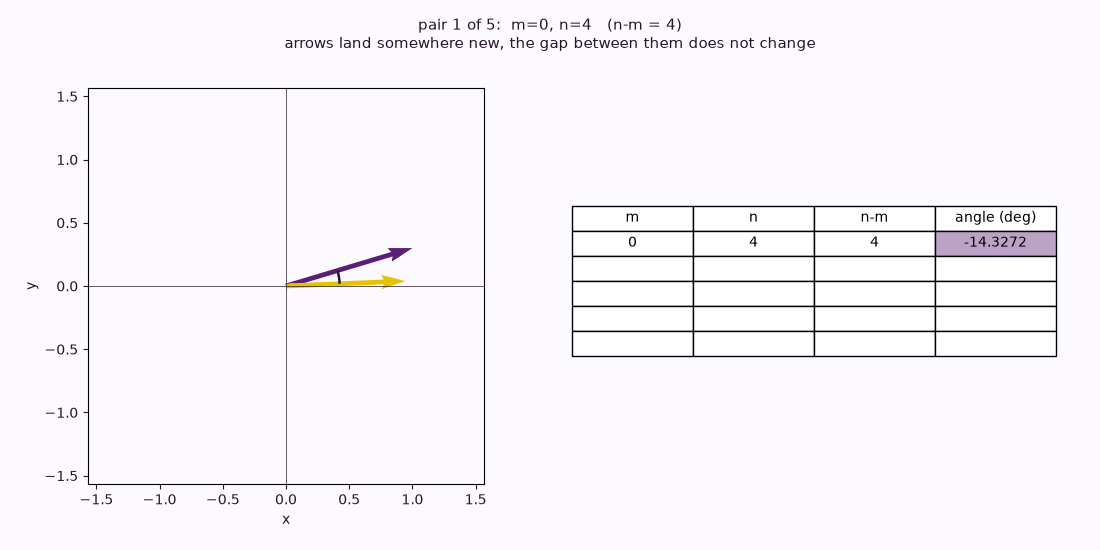

In [1]:
"""Equal relative distance yields equal angle: animated with progressive table.

Each frame jumps to a different position pair (m, n). The two arrows land
at completely different orientations from frame to frame, but the arc
between them stays the same size. Below the plot, a table fills one row
per frame with the stored values: m, n, n-m, and the measured angle.

By the last frame the table tells the story in columns: m and n vary
irregularly, n-m is constant, and the angle column repeats the exact
same number all the way down.

The pairs are deliberately not uniform shifts of one another; the only
thing they share is the difference n - m.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as equal_distance_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.patches import Arc

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "..", "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "equal_distance_animation.gif")

# === PALET WARNA BRAND ===
PRIMARY = "#5C1D74"
SECONDARY = "#E5C300"
TEXT_COLOR = "#25172A"
BG_COLOR = "#FCFAFF"


def _hex_to_rgb(h: str) -> tuple[float, float, float]:
    h = h.lstrip("#")
    return tuple(int(h[i:i + 2], 16) for i in (0, 2, 4))


def _rgb_to_hex(rgb: tuple[float, float, float]) -> str:
    return "#%02X%02X%02X" % tuple(max(0, min(255, round(c))) for c in rgb)


def _mix(c1: str, c2: str, t: float) -> str:
    """t=0 -> c1, t=1 -> c2."""
    r1, g1, b1 = _hex_to_rgb(c1)
    r2, g2, b2 = _hex_to_rgb(c2)
    return _rgb_to_hex((r1 + (r2 - r1) * t, g1 + (g2 - g1) * t, b1 + (b2 - b1) * t))


def _sequential_palette(n: int, c1: str = PRIMARY, c2: str = SECONDARY) -> list[str]:
    """N warna berurutan dari c1 ke c2, dipakai untuk membedakan N pasangan
    (m, n) satu sama lain."""
    if n <= 1:
        return [c1]
    return [_mix(c1, c2, i / (n - 1)) for i in range(n)]


def rotate_2d(v: np.ndarray, position: int, theta: float) -> np.ndarray:
    """Rotate a 2D vector by (position * theta) radians."""
    angle = position * theta
    c, s = np.cos(angle), np.sin(angle)
    rotation_matrix = np.array([[c, -s], [s, c]])
    return rotation_matrix @ v


def signed_angle_deg(u: np.ndarray, v: np.ndarray) -> float:
    """Return the angle of v relative to u in degrees, counter-clockwise positive."""
    angle_u = np.degrees(np.arctan2(u[1], u[0]))
    angle_v = np.degrees(np.arctan2(v[1], v[0]))
    return angle_v - angle_u


def build_animation(
    theta: float = 0.15,
    a0: np.ndarray = np.array([1.0, 0.3]),
    b0: np.ndarray = np.array([0.8, -0.5]),
    pairs: list[tuple[int, int]] = None,
    output_path: str = OUTPUT_PATH,
) -> None:
    if pairs is None:
        # Unrelated pairs sharing only their difference (n - m = 4).
        pairs = [(0, 4), (7, 11), (23, 27), (58, 62), (131, 135)]

    rotated = [
        (rotate_2d(a0, m, theta), rotate_2d(b0, n, theta))
        for m, n in pairs
    ]
    deltas = [signed_angle_deg(a, b) for a, b in rotated]

    # === LAYOUT: KANVAS KESELURUHAN ===
    # Lebar > tinggi -> mendukung dua panel berdampingan (bukan stack vertikal).
    fig = plt.figure(figsize=(11, 5.5))
    fig.patch.set_facecolor(BG_COLOR)

    # === LAYOUT: PANEL KIRI (quiver / vektor) ===
    # [left, bottom, width, height]. Mengisi kolom kiri, tinggi hampir penuh,
    # menyisakan ruang atas untuk fig.suptitle (lihat blok judul di bawah).
    ax_vec = fig.add_axes([0.06, 0.12, 0.40, 0.72])

    # === LAYOUT: PANEL KANAN (tabel) ===
    # Kolom kanan, disejajarkan vertikal (bottom & height sama pola dengan ax_vec)
    # supaya kedua panel terlihat rata secara visual.
    ax_table = fig.add_axes([0.52, 0.20, 0.44, 0.58])
    ax_table.axis("off")
    ax_vec.set_facecolor(BG_COLOR)
    ax_table.set_facecolor(BG_COLOR)

    max_norm = max(np.linalg.norm(a0), np.linalg.norm(b0))
    limit = 1.5 * max_norm
    ax_vec.set_xlim(-limit, limit)
    ax_vec.set_ylim(-limit, limit)
    ax_vec.set_aspect("equal")
    ax_vec.axhline(0, color=TEXT_COLOR, linewidth=0.5)
    ax_vec.axvline(0, color=TEXT_COLOR, linewidth=0.5)
    ax_vec.set_xlabel("x", color=TEXT_COLOR)
    ax_vec.set_ylabel("y", color=TEXT_COLOR)
    ax_vec.tick_params(colors=TEXT_COLOR)

    # 5-stop diskrit, satu warna per pasangan (m, n) -- dipakai untuk
    # menandai baris tabel yang aktif di tiap frame.
    row_colors = _sequential_palette(len(pairs))

    # Table: header + one row per pair, filled progressively.
    col_labels = ["m", "n", "n-m", "angle (deg)"]
    table_data = [["", "", "", ""] for _ in pairs]
    table = ax_table.table(
        cellText=table_data,
        colLabels=col_labels,
        loc="center",
        cellLoc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    def update(frame_idx: int):
        m, n = pairs[frame_idx]
        a, b = rotated[frame_idx]
        delta = deltas[frame_idx]

        # === JUDUL: fig.suptitle, bukan ax_vec.set_title ===
        # Alasan pindah: ax_vec sekarang cuma separuh lebar figure (panel kiri),
        # judul dua baris akan terpotong/menyempit kalau dipaksa muat di situ.
        # fig.suptitle mengambil lebar PENUH figure dan y=0.97 memberi margin
        # tetap dari tepi atas, jadi tidak akan mepet seperti sebelumnya.
        fig.suptitle(
            f"pair {frame_idx + 1} of {len(pairs)}:  m={m}, n={n}   (n-m = {n - m})\n"
            f"arrows land somewhere new, the gap between them does not change",
            y=0.97, fontsize=11, color=TEXT_COLOR,
        )

        # Clear dynamic artists from the previous frame.
        for artist in list(ax_vec.patches):
            artist.remove()
        for artist in list(ax_vec.collections):
            artist.remove()
        for artist in list(ax_vec.lines):
            artist.remove()

        # Redraw axes lines removed by the cleanup above.
        ax_vec.axhline(0, color=TEXT_COLOR, linewidth=0.5)
        ax_vec.axvline(0, color=TEXT_COLOR, linewidth=0.5)

        # Current pair of arrows. Vektor a selalu PRIMARY, vektor b selalu
        # SECONDARY -- warna konsisten lintas frame karena keduanya mewakili
        # peran yang sama (a0/b0 dasar), bukan kategori yang berubah per frame.
        ax_vec.quiver(0, 0, a[0], a[1], angles="xy", scale_units="xy", scale=1,
                      color=PRIMARY, width=0.012)
        ax_vec.quiver(0, 0, b[0], b[1], angles="xy", scale_units="xy", scale=1,
                      color=SECONDARY, width=0.012)

        # Arc marking the angle between them. TEXT_COLOR supaya arc terlihat
        # netral, beda dari kedua warna vektor.
        angle_a = np.degrees(np.arctan2(a[1], a[0]))
        angle_b = np.degrees(np.arctan2(b[1], b[0]))
        arc_radius = 0.45 * min(np.linalg.norm(a), np.linalg.norm(b))
        arc = Arc((0, 0), 2 * arc_radius, 2 * arc_radius,
                  angle=0, theta1=min(angle_a, angle_b), theta2=max(angle_a, angle_b),
                  color=TEXT_COLOR, linewidth=1.8)
        ax_vec.add_patch(arc)

        # Fill this frame's table row. Tint terang dari row_colors[frame_idx]
        # (bukan warna jenuh penuh) supaya teks angka tetap kontras.
        table[frame_idx + 1, 0].get_text().set_text(str(m))
        table[frame_idx + 1, 1].get_text().set_text(str(n))
        table[frame_idx + 1, 2].get_text().set_text(str(n - m))
        table[frame_idx + 1, 3].get_text().set_text(f"{delta:.4f}")
        table[frame_idx + 1, 3].set_facecolor(_mix(row_colors[frame_idx], BG_COLOR, 0.6))

        return []

    anim = FuncAnimation(
        fig, update, frames=len(pairs), interval=1200, blit=False, repeat=True
    )

    writer = PillowWriter(fps=0.8)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()

    # Auto-display in Colab/Jupyter without needing a separate cell.
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()

In [ ]:
"""Animated attention heatmaps, correct vs mismatched positions (imshow +
colorbar, subplots(1,2)).

Scenario: a KV cache of prefix + suffix tokens is truncated to the
suffix. The remaining keys keep the rotations from their original
absolute positions. The model then decodes several steps. Each decode
step computes attention weights over the same fixed keys, using either:

  left panel  : the correct query position (continuing the full history)
  right panel : a query position derived from the truncated cache length

Each frame adds one row to both heatmaps: row t = attention weights of
decode step t over the suffix keys. Color scale is shared. The rows fill
top to bottom as decoding proceeds, so by the last frame the two panels
show the full weight matrices side by side and the drift between them is
visible as a different color pattern, not as any error or crash.

Self-contained for Google Colab. Run the whole file in one cell; the GIF
displays inline and is saved as attention_mismatch_animation.gif.
"""

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation, PillowWriter

import os

try:
    _THIS_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    # __file__ is undefined when this script is exec()'d or pasted into a
    # notebook/Colab cell rather than run as a standalone file. Fall back
    # to the current working directory in that case.
    _THIS_DIR = os.getcwd()
_ASSETS_DIR = os.path.join(_THIS_DIR, "..", "assets")
os.makedirs(_ASSETS_DIR, exist_ok=True)
OUTPUT_PATH = os.path.join(_ASSETS_DIR, "attention_mismatch_animation.gif")


def inverse_frequencies(dim: int, base: float = 10000.0) -> np.ndarray:
    i = np.arange(dim // 2)
    return base ** (-2.0 * i / dim)


def apply_rope(x: np.ndarray, position: int, freqs: np.ndarray) -> np.ndarray:
    """Adjacent-pair rotary encoding on a single vector."""
    out = np.empty_like(x)
    angles = position * freqs
    cos, sin = np.cos(angles), np.sin(angles)
    x_even, x_odd = x[0::2], x[1::2]
    out[0::2] = x_even * cos - x_odd * sin
    out[1::2] = x_even * sin + x_odd * cos
    return out


def attention_weights(query: np.ndarray, query_position: int,
                      keys: np.ndarray, key_positions: np.ndarray,
                      freqs: np.ndarray) -> np.ndarray:
    """Softmax attention weights of one query over a fixed set of keys.

    Identity projections: the only transformation is the rotary encoding,
    so any difference between two runs is attributable to positions alone.
    """
    dim = query.shape[-1]
    q = apply_rope(query, query_position, freqs)
    scores = np.array([
        np.dot(q, apply_rope(keys[j], int(key_positions[j]), freqs))
        for j in range(keys.shape[0])
    ]) / np.sqrt(dim)
    exp = np.exp(scores - scores.max())
    return exp / exp.sum()


def build_animation(
    dim: int = 16,
    prefix_len: int = 20,
    suffix_len: int = 12,
    n_decode_steps: int = 10,
    seed: int = 0,
    output_path: str = OUTPUT_PATH,
) -> None:
    rng = np.random.default_rng(seed)
    freqs = inverse_frequencies(dim)
    total = prefix_len + suffix_len

    keys = rng.normal(size=(suffix_len, dim)) * 0.5
    queries = rng.normal(size=(n_decode_steps, dim)) * 0.5

    # Cached keys keep their original absolute positions.
    key_positions = np.arange(prefix_len, total)

    weights_correct = np.full((n_decode_steps, suffix_len), np.nan)
    weights_buggy = np.full((n_decode_steps, suffix_len), np.nan)
    for t in range(n_decode_steps):
        weights_correct[t] = attention_weights(
            queries[t], total + t, keys, key_positions, freqs)
        weights_buggy[t] = attention_weights(
            queries[t], suffix_len + t, keys, key_positions, freqs)

    vmax = max(weights_correct.max(), weights_buggy.max())

    fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(10, 5), dpi=150)
    fig.suptitle(
        "Attention weights per decode step over the same cached keys.\n"
        "Left: correct query positions. Right: positions from truncated cache length.",
        fontsize=10,
    )

    masked = np.full_like(weights_correct, np.nan)
    im_l = ax_l.imshow(masked.copy(), vmin=0, vmax=vmax, aspect="auto",
                       cmap="viridis", interpolation="nearest")
    im_r = ax_r.imshow(masked.copy(), vmin=0, vmax=vmax, aspect="auto",
                       cmap="viridis", interpolation="nearest")

    for ax, title in ((ax_l, "correct positions"), (ax_r, "mismatched positions")):
        ax.set_xlabel("key index (cached suffix tokens)", fontsize=9)
        ax.set_ylabel("decode step", fontsize=9)
        ax.set_title(title, fontsize=10)
        ax.set_xticks(range(suffix_len))
        ax.set_yticks(range(n_decode_steps))
        ax.tick_params(labelsize=7)

    fig.colorbar(im_l, ax=[ax_l, ax_r], shrink=0.8, label="attention weight")

    def update(frame_idx: int):
        shown_correct = np.full_like(weights_correct, np.nan)
        shown_buggy = np.full_like(weights_buggy, np.nan)
        shown_correct[: frame_idx + 1] = weights_correct[: frame_idx + 1]
        shown_buggy[: frame_idx + 1] = weights_buggy[: frame_idx + 1]
        im_l.set_data(shown_correct)
        im_r.set_data(shown_buggy)
        return [im_l, im_r]

    anim = FuncAnimation(fig, update, frames=n_decode_steps,
                         interval=600, blit=False, repeat=True)
    writer = PillowWriter(fps=1.6)
    anim.save(output_path, writer=writer)
    plt.close(fig)
    print(f"wrote {output_path}")


def main() -> None:
    build_animation()
    try:
        from IPython.display import Image as IPImage
        from IPython.display import display
        display(IPImage(OUTPUT_PATH))
    except ImportError:
        pass


if __name__ == "__main__":
    main()
